# Exploring Sales Determinants and Predicting Revenue in Retail Businesses



In [ ]:
import pandas as pd

try:
    df = pd.read_csv('supermarket_sales.csv')
    print("Loaded from current directory")
except FileNotFoundError:
    df = pd.read_csv('/content/supermarket_sales.csv')
    print("Loaded from /content")

Loaded from current directory


---
## 1. Data Preparation

1.1. Importing Libraries and Loading Dataset

In [ ]:
# Import all required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

# Load dataset
df_raw = pd.read_csv('supermarket_sales.csv')
print(f"Dataset loaded successfully!")
print(f"Number of Rows   : {df_raw.shape[0]}")
print(f"Number of Columns: {df_raw.shape[1]}")
print(f"\nColumn Names:")
for col in df_raw.columns:
    print(f"  - {col}")

Dataset loaded successfully!
Number of Rows   : 1000
Number of Columns: 17

Column Names:
  - Invoice ID
  - Branch
  - City
  - Customer type
  - Gender
  - Product line
  - Unit price
  - Quantity
  - Tax 5%
  - Sales
  - Date
  - Time
  - Payment
  - cogs
  - gross margin percentage
  - gross income
  - Rating


In [ ]:
# First look at the data
df_raw.head()

---
## 2. Data Cleaning


### 2.1 Duplicate Row Check

In [ ]:
# Create df_full from raw data
df_full = df_raw.copy()

# Duplicate check
print("Duplicates:", df_full.duplicated().sum())

df_full = df_full.drop_duplicates()
print("Shape after removing duplicates:", df_full.shape)

Duplicates: 0
Shape after removing duplicates: (1000, 17)


### 2.2 Missing Value Detection

In [ ]:
# Missing values check
miss_val= (df_full.isnull().sum())
print(miss_val)

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


**2.3. Column Check**

In [ ]:
# Column check
print(df_full.columns)

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')


**2.4. Column Renaming**

In [ ]:
rename_map = {
    'Invoice ID': 'invoice_id',
    'Branch': 'branch',
    'City': 'city',
    'Customer type': 'customer_type',
    'Gender': 'gender',
    'Product line': 'product_line',
    'Unit price': 'unit_price',
    'Quantity': 'quantity',
    'Tax 5%': 'tax_5pct',
    'Sales': 'sales',
    'Date': 'date',
    'Time': 'time',
    'Payment': 'payment',
    'cogs': 'cogs',
    'gross margin percentage': 'gross_margin_pct',
    'gross income': 'gross_income',
    'Rating': 'rating',
    'Revenue': 'revenue'
}

df_full.rename(columns=rename_map, inplace=True)

print("Columns renamed:")
print(list(df_full.columns))

Columns renamed:
['invoice_id', 'branch', 'city', 'customer_type', 'gender', 'product_line', 'unit_price', 'quantity', 'tax_5pct', 'sales', 'date', 'time', 'payment', 'cogs', 'gross_margin_pct', 'gross_income', 'rating']


### 2.4 Data Type Correction

In [ ]:
def engineer_datetime_features(df):
    df = df.copy()

    df['date'] = pd.to_datetime(df['date'])

    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek
    df['hour'] = pd.to_datetime(df['time'], format='%I:%M:%S %p').dt.hour

    return df


df_full = df_raw.copy()
df_full.rename(columns=rename_map, inplace=True)

df_full = engineer_datetime_features(df_full)

print("Datetime features engineered successfully.")
print(df_full[['date', 'month', 'day_of_week', 'hour']].head(3))
print(df_full.dtypes)

Datetime features engineered successfully.
        date  month  day_of_week  hour
0 2019-01-05      1            5    13
1 2019-03-08      3            4    10
2 2019-03-03      3            6    13
invoice_id                  object
branch                      object
city                        object
customer_type               object
gender                      object
product_line                object
unit_price                 float64
quantity                     int64
tax_5pct                   float64
sales                      float64
date                datetime64[ns]
time                        object
payment                     object
cogs                       float64
gross_margin_pct           float64
gross_income               float64
rating                     float64
month                        int32
day_of_week                  int32
hour                         int32
dtype: object


### 2.5 Dropping Irrelevant Columns

In [ ]:
# Drop non-predictive
# - invoice_id       : unique transaction ID, no predictive value
# - date, time       : replaced by engineered features (month, day_of_week, hour)
# - gross_margin_pct : constant (~4.76%), zero variance
# - tax_5pct, sales, cogs, gross_income : directly derived from unit_price*quantity → data leakage

# Drop non-predictive / leakage columns

cols_to_drop = [
    'invoice_id',
    'date',
    'time',
    'gross_margin_pct',
    'tax_5pct',
    'sales',
    'cogs',
    'gross_income'
]

df_full = df_full.drop(columns=cols_to_drop, errors='ignore')

print("Remaining columns:", list(df_full.columns))
print("Shape:", df_full.shape)

Remaining columns: ['branch', 'city', 'customer_type', 'gender', 'product_line', 'unit_price', 'quantity', 'payment', 'rating', 'month', 'day_of_week', 'hour']
Shape: (1000, 12)


**Dataset Overview After Data Cleaning**

In [ ]:
import pandas as pd

# Basic summary
overview = pd.DataFrame({
    "Column": df_full.columns,
    "Data Type": df_full.dtypes.values,
    "Missing Values": df_full.isnull().sum().values,
})

print("Dataset Overview After Cleaning")
overview

Dataset Overview After Cleaning


,Column,Data Type,Missing Values
0,branch,object,0
1,city,object,0
2,customer_type,object,0
3,gender,object,0
4,product_line,object,0
5,unit_price,float64,0
6,quantity,int64,0
7,payment,object,0
8,rating,float64,0
9,month,int32,0


### 2.6 Target Variable Creation

Revenue = Unit Price × Quantity

### 2.6 Feature and Target Definition

 The **target variable** (y) is defined as transaction revenue (**Revenue** = Unit Price x Quantity). The input features (X) consists of all the independent variables thar are remained after removing dropping irrelevant columns.

In [ ]:
# Add Revenue target
# (Revenue = Unit price × Quantity, computed before split — no leakage)
df_full['revenue'] = df_full['unit_price'] * df_full['quantity']


### 2.8 Feature Selection

---
## 4. KDE Plots of Numerical Features

Kernel Density Estimation (KDE) plots show the **probability density** of each numerical feature — a smooth, continuous version of a histogram. They help identify:
- The shape of the distribution (normal, skewed, bimodal)
- Concentration of values
- Presence of multiple peaks (multimodality)

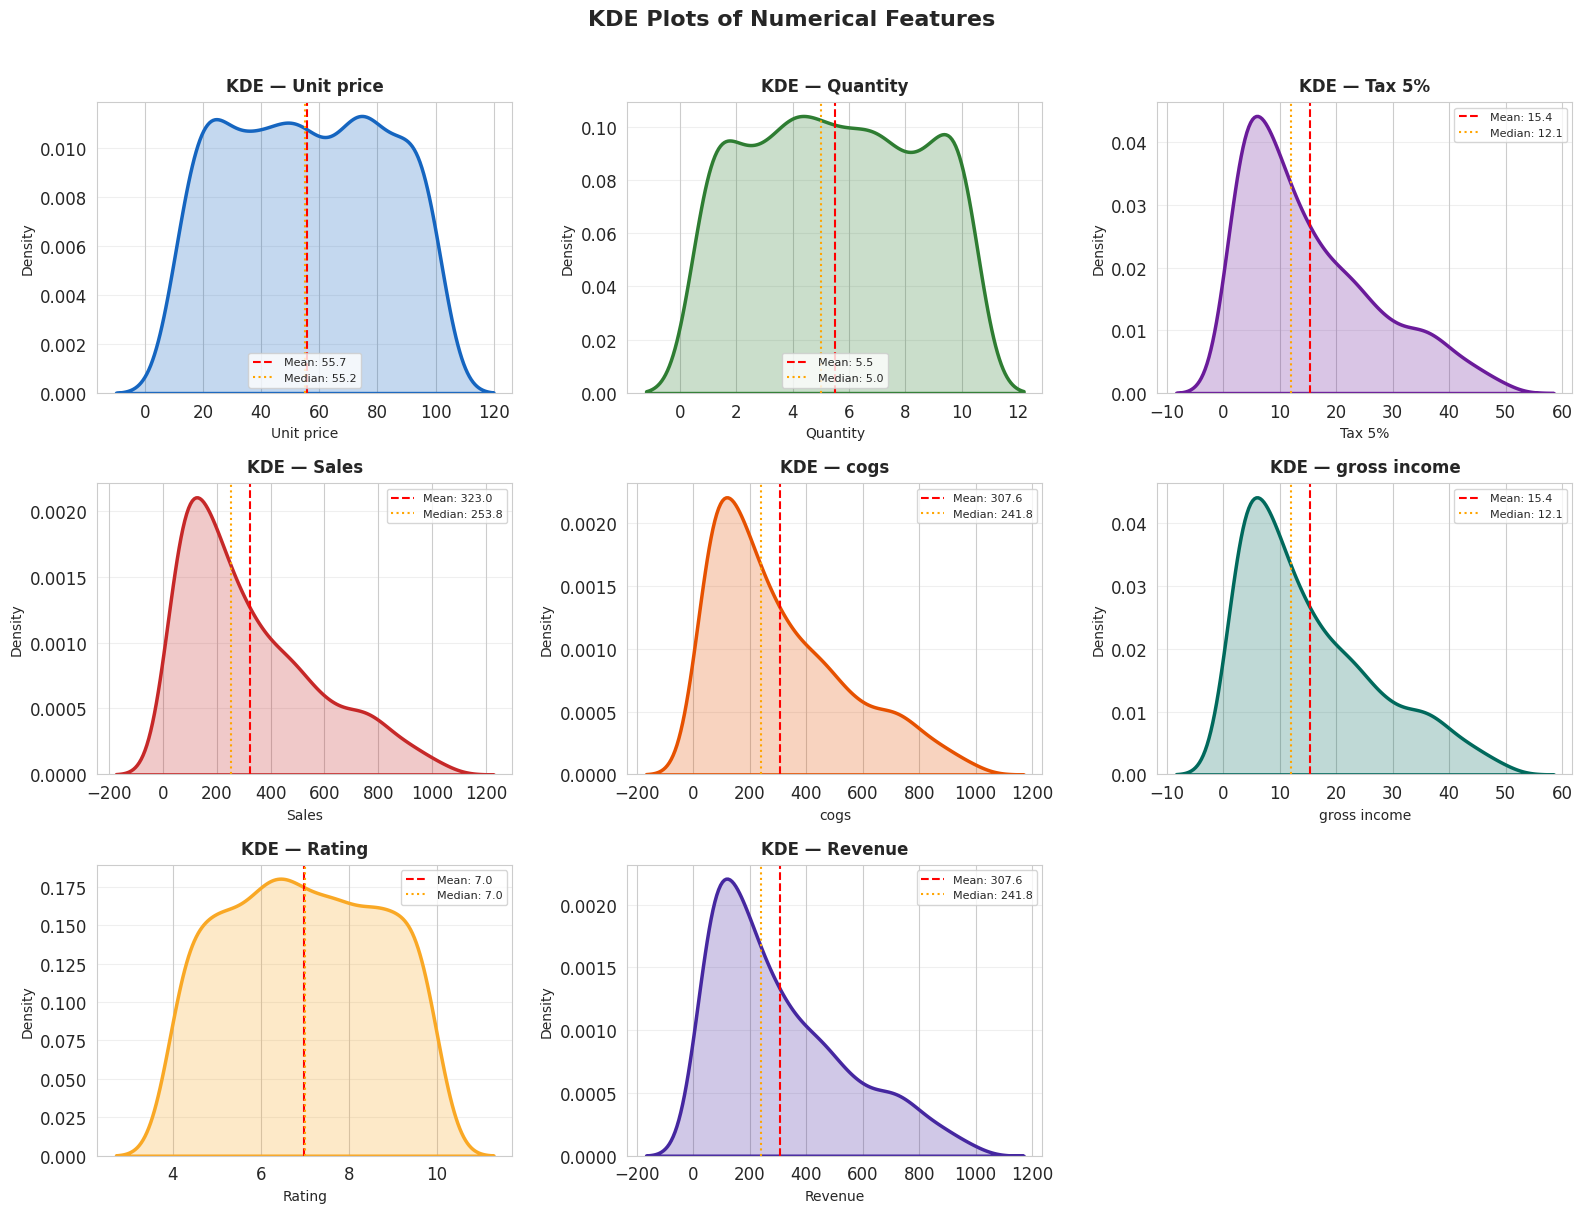

In [ ]:
# KDE plots for all numerical features
num_df = df_raw[['Unit price', 'Quantity', 'Tax 5%', 'Sales', 'cogs', 'gross income', 'Rating']].copy()
num_df['Revenue'] = df_raw['Unit price'] * df_raw['Quantity']

numerical_cols = num_df.columns.tolist()
n_cols = 3
n_rows = -(-len(numerical_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

palette = ['#1565C0', '#2E7D32', '#6A1B9A', '#C62828', '#E65100', '#00695C', '#F9A825', '#4527A0']

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    color = palette[i % len(palette)]

    # KDE curve
    sns.kdeplot(num_df[col], ax=ax, color=color, linewidth=2.5, fill=True, alpha=0.25)

    # Vertical lines for mean and median
    mean_val = num_df[col].mean()
    med_val  = num_df[col].median()
    ax.axvline(mean_val, color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.axvline(med_val,  color='orange', linestyle=':',  linewidth=1.5, label=f'Median: {med_val:.1f}')

    ax.set_title(f'KDE — {col}', fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# Hide any unused subplots
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('KDE Plots of Numerical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

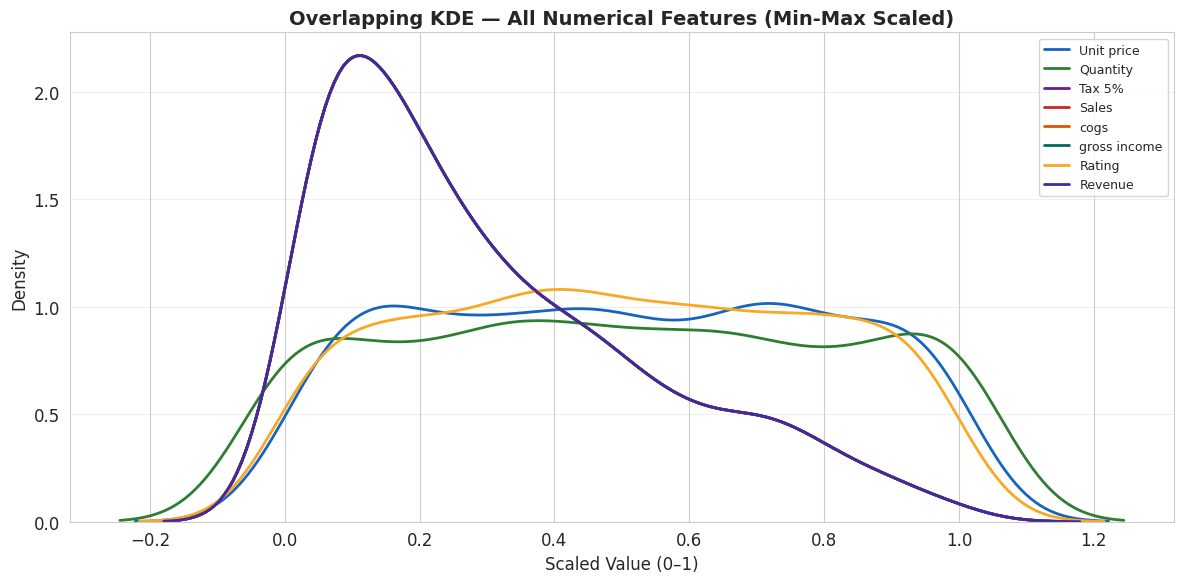

Feature                  Mean   Median   Skewness   Kurtosis
------------------------------------------------------------
Unit price              55.67    55.23      0.007     -1.219
Quantity                 5.51     5.00      0.013     -1.215
Tax 5%                  15.38    12.09      0.891     -0.087
Sales                  322.97   253.85      0.891     -0.087
cogs                   307.59   241.76      0.891     -0.087
gross income            15.38    12.09      0.891     -0.087
Rating                   6.97     7.00      0.009     -1.152
Revenue                307.59   241.76      0.891     -0.087


In [ ]:
# Overlapping KDE — compare distributions on same scale (normalised)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled = pd.DataFrame(scaler.fit_transform(num_df), columns=num_df.columns)

fig, ax = plt.subplots(figsize=(12, 6))
for i, col in enumerate(scaled.columns):
    sns.kdeplot(scaled[col], ax=ax, label=col,
                linewidth=2, fill=False, color=palette[i % len(palette)])

ax.set_title('Overlapping KDE — All Numerical Features (Min-Max Scaled)', fontsize=14, fontweight='bold')
ax.set_xlabel('Scaled Value (0–1)')
ax.set_ylabel('Density')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary of distribution shape
from scipy.stats import skew, kurtosis
print(f"{'Feature':<20} {'Mean':>8} {'Median':>8} {'Skewness':>10} {'Kurtosis':>10}")
print("-" * 60)
for col in num_df.columns:
    s = skew(num_df[col])
    k = kurtosis(num_df[col])
    print(f"{col:<20} {num_df[col].mean():>8.2f} {num_df[col].median():>8.2f} {s:>10.3f} {k:>10.3f}")

---
## 3. Descriptive Statistics
### 3.1 Summary Statistics

In [34]:
# Reconstruct readable df for stats using original data
stats_df = df_raw[['Unit price', 'Quantity', 'Rating']].copy()
stats_df['Revenue'] = df_raw['Unit price'] * df_raw['Quantity']

print("=== Summary Statistics ===")
stats_df.describe().round(2)

=== Summary Statistics ===


,Unit price,Quantity,Rating,Revenue
count,1000.00,1000.00,1000.00,1000.00
mean,55.67,5.51,6.97,307.59
std,26.49,2.92,1.72,234.18
min,10.08,1.00,4.00,10.17
25%,32.88,3.00,5.50,118.50
50%,55.23,5.00,7.00,241.76
75%,77.94,8.00,8.50,448.90
max,99.96,10.00,10.00,993.00


#Central Tendency

In [44]:
rev = stats_df['Revenue']
print("=== Central Tendency of Revenue ===")
print(f"Mean Revenue   : ${rev.mean():.2f}")
print(f"Median Revenue : ${rev.median():.2f}")
print()
print("Interpretation:")
print(f"  The mean (${rev.mean():.2f}) is slightly higher than the median (${rev.median():.2f}),")
print("  indicating a mild right skew — a few high-value transactions pull the average up.")

=== Central Tendency of Revenue ===
Mean Revenue   : $307.59
Median Revenue : $241.76

Interpretation:
  The mean ($307.59) is slightly higher than the median ($241.76),
  indicating a mild right skew — a few high-value transactions pull the average up.


### 3.3 Dispersion

In [45]:
rev = df_train["revenue"]

q1 = rev.quantile(0.25)
q3 = rev.quantile(0.75)
iqr = q3 - q1

print("=== Revenue Dispersion ===")
print(f"Variance          : {rev.var():.2f}")
print(f"Standard Deviation: ${rev.std():.2f}")
print(f"Range             : ${rev.min():.2f} – ${rev.max():.2f}")
print(f"IQR               : ${iqr:.2f}")

=== Revenue Dispersion ===
Variance          : 53731.31
Standard Deviation: $231.80
Range             : $12.09 – $993.00
IQR               : $332.77


---
## 5. Exploratory Data Analysis (EDA)

### 4.1 Revenue Distribution

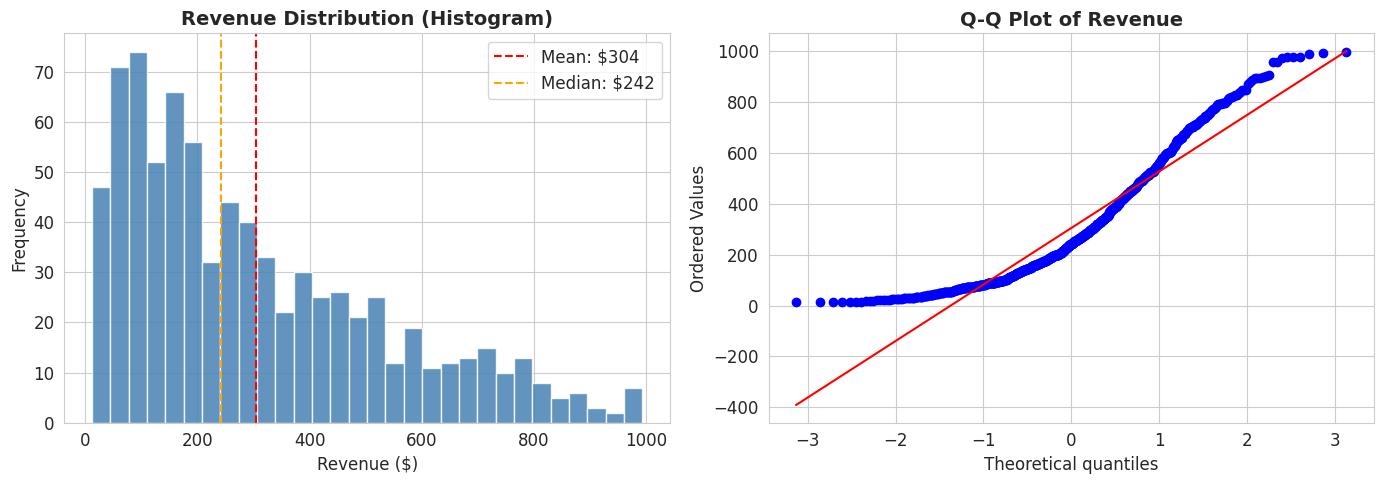

Skewness : 0.917 — Right skewed (positive)
Kurtosis : 0.012


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(rev, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Revenue Distribution (Histogram)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Revenue ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(rev.mean(), color='red', linestyle='--', label=f'Mean: ${rev.mean():.0f}')
axes[0].axvline(rev.median(), color='orange', linestyle='--', label=f'Median: ${rev.median():.0f}')
axes[0].legend()

from scipy import stats as scipy_stats
scipy_stats.probplot(rev, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Revenue', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

from scipy.stats import skew, kurtosis
print(f"Skewness : {skew(rev):.3f} — {'Right skewed (positive)' if skew(rev)>0 else 'Left skewed'}")
print(f"Kurtosis : {kurtosis(rev):.3f}")

### 4.2 Payment Method Distribution

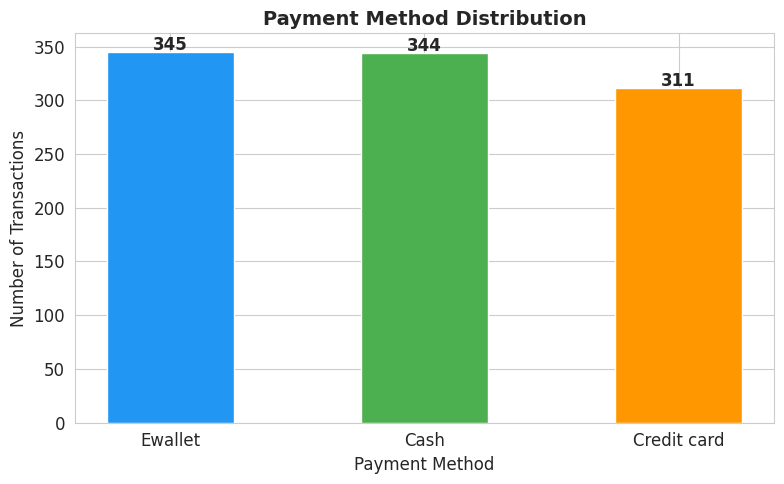

Payment Method Counts:
Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64

Most common: Ewallet (345 transactions)


In [47]:
payment_counts = df_raw['Payment'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(payment_counts.index, payment_counts.values,
              color=['#2196F3', '#4CAF50', '#FF9800'], edgecolor='white', width=0.5)
ax.set_title('Payment Method Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Payment Method')
ax.set_ylabel('Number of Transactions')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(int(bar.get_height())), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Payment Method Counts:")
print(payment_counts)
print(f"\nMost common: {payment_counts.idxmax()} ({payment_counts.max()} transactions)")

### 4.3 Revenue by Product Line

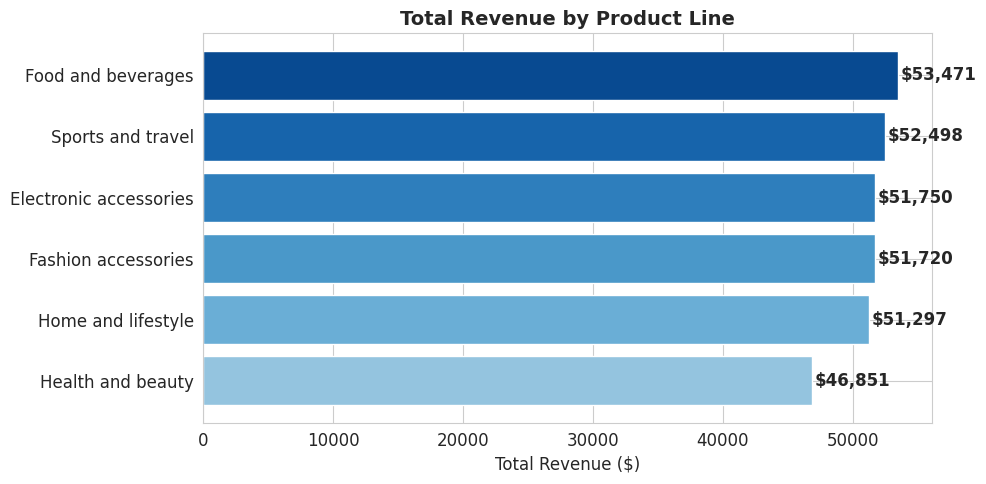

Highest revenue product line: Food and beverages ($53,471.28)


In [48]:
rev_by_product = df_raw.copy()
rev_by_product['Revenue'] = rev_by_product['Unit price'] * rev_by_product['Quantity']
product_rev = rev_by_product.groupby('Product line')['Revenue'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(product_rev)))
bars = ax.barh(product_rev.index, product_rev.values, color=colors, edgecolor='white')
ax.set_title('Total Revenue by Product Line', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue ($)')
for bar, val in zip(bars, product_rev.values):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Highest revenue product line: {product_rev.idxmax()} (${product_rev.max():,.2f})")

### 4.4 Revenue by City

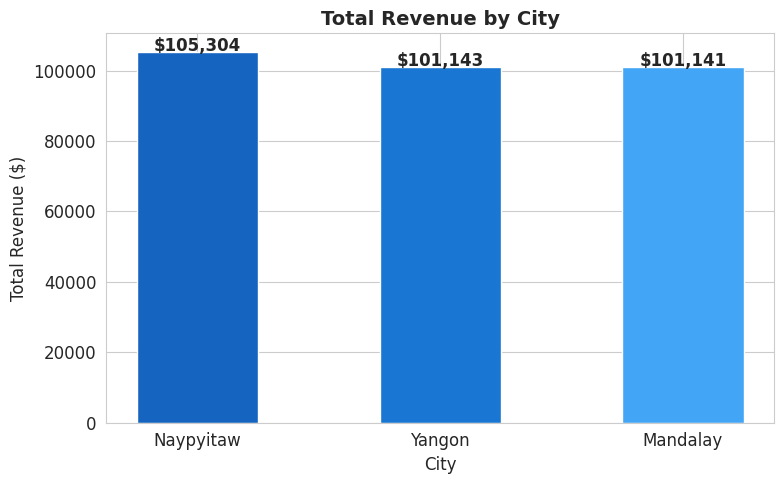

Highest revenue city: Naypyitaw ($105,303.53)


In [49]:
city_rev = rev_by_product.groupby('City')['Revenue'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(city_rev.index, city_rev.values,
              color=['#1565C0', '#1976D2', '#42A5F5'], edgecolor='white', width=0.5)
ax.set_title('Total Revenue by City', fontsize=14, fontweight='bold')
ax.set_xlabel('City')
ax.set_ylabel('Total Revenue ($)')
for bar, val in zip(bars, city_rev.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'${val:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Highest revenue city: {city_rev.idxmax()} (${city_rev.max():,.2f})")

### 4.5 Revenue by Gender

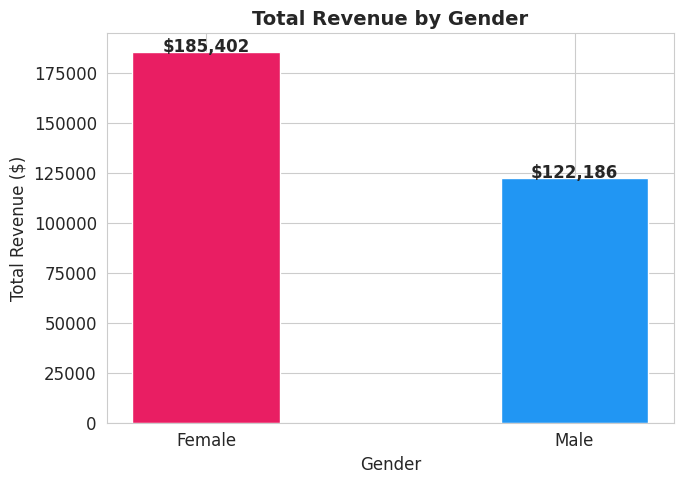

Higher spending segment: Female ($185,401.75)


In [50]:
gender_rev = rev_by_product.groupby('Gender')['Revenue'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(gender_rev.index, gender_rev.values,
              color=['#E91E63', '#2196F3'], edgecolor='white', width=0.4)
ax.set_title('Total Revenue by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender')
ax.set_ylabel('Total Revenue ($)')
for bar, val in zip(bars, gender_rev.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'${val:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Higher spending segment: {gender_rev.idxmax()} (${gender_rev.max():,.2f})")

### 4.6 Quantity vs Revenue

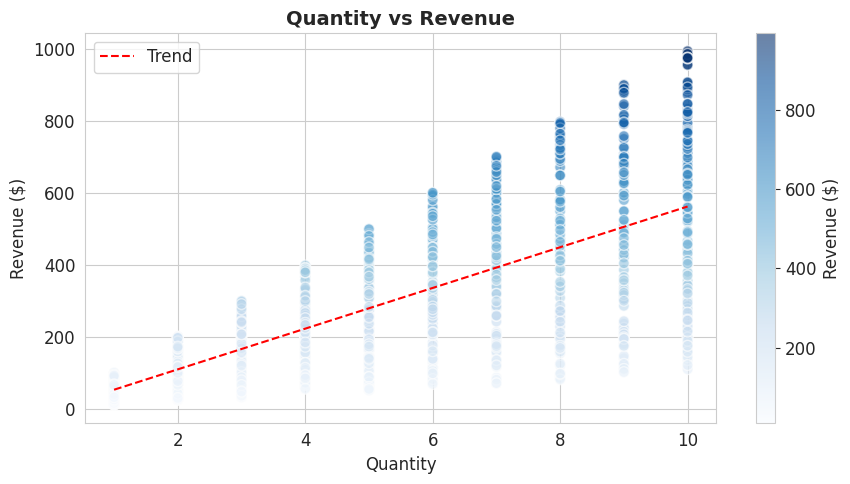

Pearson Correlation (Quantity vs Revenue): 0.7055


In [51]:
fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(df_raw['Quantity'], rev_by_product['Revenue'],
                     c=rev_by_product['Revenue'], cmap='Blues', alpha=0.6, edgecolor='white', s=60)
plt.colorbar(scatter, label='Revenue ($)')
ax.set_title('Quantity vs Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Quantity')
ax.set_ylabel('Revenue ($)')

# Add trend line
z = np.polyfit(df_raw['Quantity'], rev_by_product['Revenue'], 1)
p = np.poly1d(z)
xline = np.linspace(df_raw['Quantity'].min(), df_raw['Quantity'].max(), 100)
ax.plot(xline, p(xline), 'r--', linewidth=1.5, label='Trend')
ax.legend()
plt.tight_layout()
plt.show()

corr = df_raw['Quantity'].corr(rev_by_product['Revenue'])
print(f"Pearson Correlation (Quantity vs Revenue): {corr:.4f}")

### 4.7 Unit Price vs Revenue

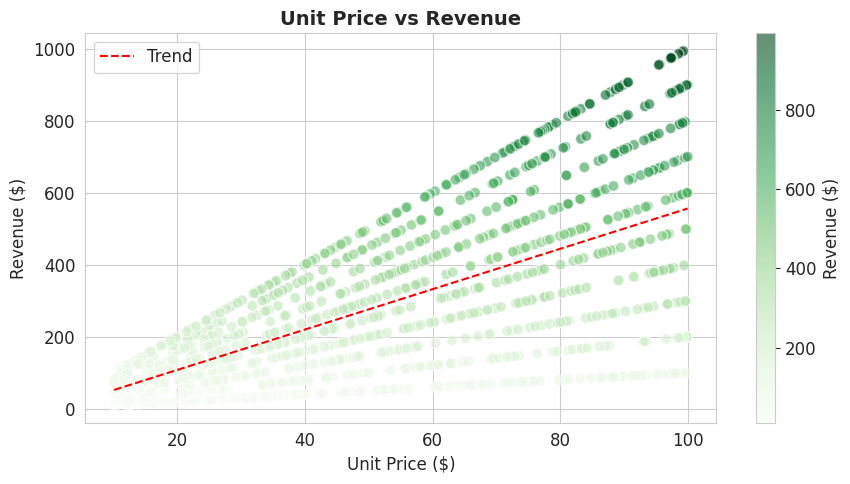

Pearson Correlation (Unit Price vs Revenue): 0.6340


In [52]:
fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(df_raw['Unit price'], rev_by_product['Revenue'],
                     c=rev_by_product['Revenue'], cmap='Greens', alpha=0.6, edgecolor='white', s=60)
plt.colorbar(scatter, label='Revenue ($)')
ax.set_title('Unit Price vs Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Unit Price ($)')
ax.set_ylabel('Revenue ($)')

z2 = np.polyfit(df_raw['Unit price'], rev_by_product['Revenue'], 1)
p2 = np.poly1d(z2)
xline2 = np.linspace(df_raw['Unit price'].min(), df_raw['Unit price'].max(), 100)
ax.plot(xline2, p2(xline2), 'r--', linewidth=1.5, label='Trend')
ax.legend()
plt.tight_layout()
plt.show()

corr2 = df_raw['Unit price'].corr(rev_by_product['Revenue'])
print(f"Pearson Correlation (Unit Price vs Revenue): {corr2:.4f}")

### 2.9 Summary

Preprocessing complete. The train-test split was performed in **Section 1.4** (before any preprocessing) to prevent data leakage. Label Encoding was fit exclusively on the training set and then applied to the test set.

### 3.2 Central Tendency

### 2.6 Train-Test Split

The dataset is split into **80% (800 rows)** for **training** and **20% (200 rows)** data for **testing** the model using random_state = 42. This splitting is executed on the raw data before any preprocessing occurs to prevent data leakage.

In [53]:


df_train, df_test = train_test_split(df_full, test_size=0.2, random_state=42)

print(f"Total rows    : {len(df_full)}")
print(f"Training rows : {len(df_train)} ({len(df_train)/len(df_full)*100:.0f}%)")
print(f"Testing  rows : {len(df_test)} ({len(df_test)/len(df_full)*100:.0f}%)")
print("\nSplit done — preprocessing will now be applied separately to each set.")

print(df_train.columns.tolist())

Total rows    : 1000
Training rows : 800 (80%)
Testing  rows : 200 (20%)

Split done — preprocessing will now be applied separately to each set.
['invoice_id', 'branch', 'city', 'customer_type', 'gender', 'product_line', 'unit_price', 'quantity', 'tax_5pct', 'sales', 'date', 'time', 'payment', 'cogs', 'gross_margin_pct', 'gross_income', 'rating', 'month', 'day_of_week', 'hour', 'revenue']


### 2.7 Label Encoding

In [54]:
from sklearn.preprocessing import LabelEncoder
# Standardize column names
df_train.columns = (
    df_train.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

df_test.columns = (
    df_test.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# Categorical columns
categorical_cols = [
    'branch',
    'city',
    'customer_type',
    'gender',
    'product_line',
    'payment'
]

encoding_map = {}

for col in categorical_cols:
    le = LabelEncoder()

    # Fit on train and transform train
    df_train[col] = le.fit_transform(df_train[col])

    # Transform test using same encoder
    df_test[col] = le.transform(df_test[col])

    # Save mapping
    encoding_map[col] = {
        cls: int(code)
        for cls, code in zip(le.classes_, le.transform(le.classes_))
    }

print("Label Encoding Complete\n")

for col, mapping in encoding_map.items():
    print(f"{col}: {mapping}")

# ── Feature Selection (done HERE, after encoding) ──────────────────
feature_cols = ['branch', 'city', 'customer_type', 'gender', 'product_line',
                'unit_price', 'quantity', 'payment', 'rating', 'month', 'day_of_week', 'hour']

X_train = df_train[feature_cols]
y_train = df_train['revenue']

X_test  = df_test[feature_cols]
y_test  = df_test['revenue']

print(f"\nX_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}  | y_test : {y_test.shape}")
print(f"\nFeatures: {feature_cols}")


Label Encoding Complete

branch: {'Alex': 0, 'Cairo': 1, 'Giza': 2}
city: {'Mandalay': 0, 'Naypyitaw': 1, 'Yangon': 2}
customer_type: {'Member': 0, 'Normal': 1}
gender: {'Female': 0, 'Male': 1}
product_line: {'Electronic accessories': 0, 'Fashion accessories': 1, 'Food and beverages': 2, 'Health and beauty': 3, 'Home and lifestyle': 4, 'Sports and travel': 5}
payment: {'Cash': 0, 'Credit card': 1, 'Ewallet': 2}

X_train: (800, 12) | y_train: (800,)
X_test : (200, 12)  | y_test : (200,)

Features: ['branch', 'city', 'customer_type', 'gender', 'product_line', 'unit_price', 'quantity', 'payment', 'rating', 'month', 'day_of_week', 'hour']


---
## 6. Correlation Analysis

### 7.1 Correlation Matrix Heatmap

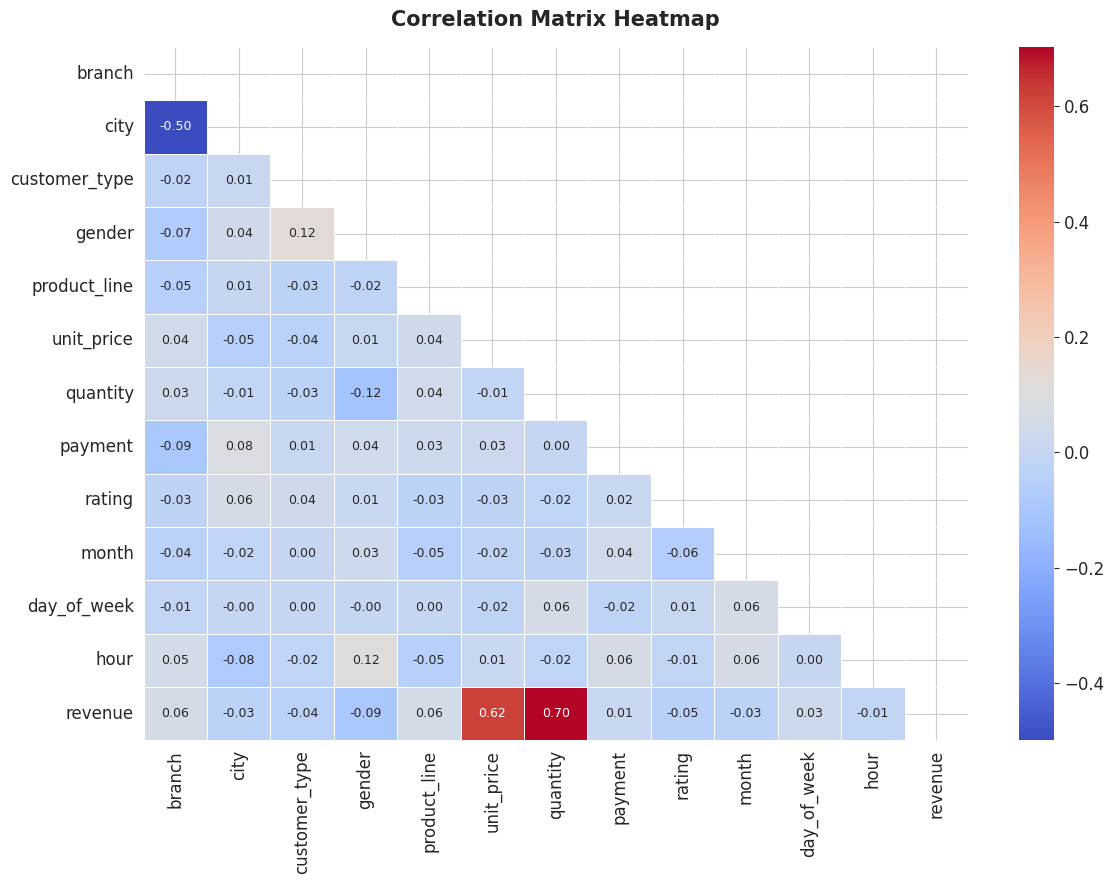


Top Correlations with Revenue:
quantity         0.7029
unit_price       0.6212
gender          -0.0949
branch           0.0563
product_line     0.0553
rating          -0.0473
customer_type   -0.0377
month           -0.0332
city            -0.0326
day_of_week      0.0311
payment          0.0147
hour            -0.0127
Name: revenue, dtype: float64


In [55]:
# Build a numeric dataframe for correlation
# Use training set for correlation (already encoded and preprocessed)
corr_df = X_train.copy()
corr_df['revenue'] = y_train.values

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title('Correlation Matrix Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\nTop Correlations with Revenue:")
rev_corr = corr_matrix['revenue'].drop('revenue').sort_values(key=abs, ascending=False)
print(rev_corr.round(4))

---
## 7. Outlier Analysis

### 7.1–6.3 Outlier Box Plots

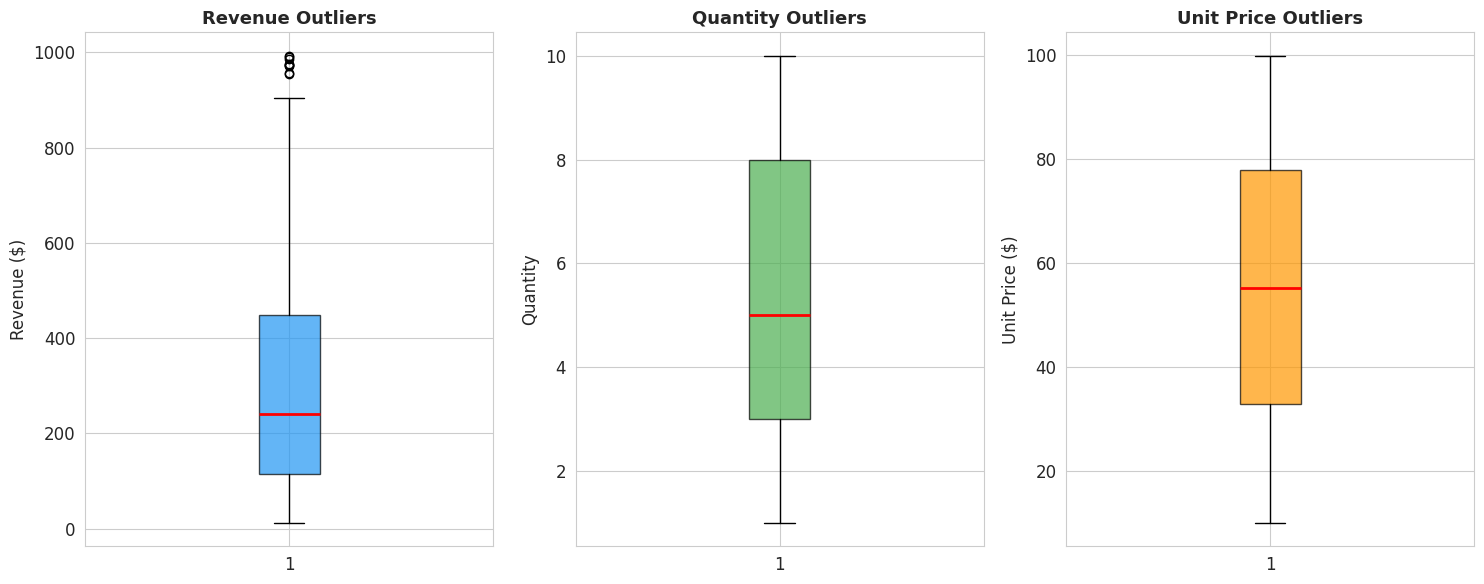

Outlier counts (IQR method):
  Revenue    : 9 outliers
  Quantity   : 0 outliers
  Unit Price : 0 outliers

Decision: Outliers RETAINED — they represent genuine high-value transactions,
not data errors. Removing them would reduce the model's ability to predict extreme cases.


In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Revenue
axes[0].boxplot(rev, patch_artist=True,
                boxprops=dict(facecolor='#2196F3', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Revenue Outliers', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue ($)')

# Quantity
axes[1].boxplot(df_raw['Quantity'], patch_artist=True,
                boxprops=dict(facecolor='#4CAF50', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Quantity Outliers', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Quantity')

# Unit Price
axes[2].boxplot(df_raw['Unit price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9800', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Unit Price Outliers', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Unit Price ($)')

plt.tight_layout()
plt.show()

def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

print("Outlier counts (IQR method):")
print(f"  Revenue    : {count_outliers(rev)} outliers")
print(f"  Quantity   : {count_outliers(df_raw['Quantity'])} outliers")
print(f"  Unit Price : {count_outliers(df_raw['Unit price'])} outliers")
print()
print("Decision: Outliers RETAINED — they represent genuine high-value transactions,")
print("not data errors. Removing them would reduce the model's ability to predict extreme cases.")

---
## 8. Model Development

### 8.1 Random Forest Regressor

**Why Random Forest?**
- Handles both numerical and encoded categorical features natively
- Robust to outliers and non-linear relationships
- Built-in feature importance for interpretability
- Ensemble of decision trees reduces overfitting vs. a single tree
- Works well on small-to-medium tabular datasets without extensive preprocessing

**Key Parameters:**
| Parameter | Value | Reason |
|---|---|---|
| n_estimators | 200 | More trees → more stable predictions |
| max_depth | 12 | Limits tree depth to prevent overfitting |
| min_samples_split | 4 | Requires 4 samples to split a node |
| min_samples_leaf | 2 | Requires 2 samples per leaf |
| random_state | 42 | Reproducibility |

### 8.2 Model Training

In [57]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

rf.fit(X_train, y_train)
print("Model training complete!")
print(f"Number of trees: {rf.n_estimators}")
print(f"Max depth      : {rf.max_depth}")

Model training complete!
Number of trees: 200
Max depth      : 10


---
## 9. Model Evaluation

### 9.1 Performance Metrics

In [58]:
# Predictions
y_train_pred = rf.predict(X_train)
y_pred = rf.predict(X_test)

# Metrics
print("Out-of-Bag Score:", rf.oob_score_)
train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test, y_pred)
train_mae  = mean_absolute_error(y_train, y_train_pred)
test_mae   = mean_absolute_error(y_test, y_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test, y_pred))

metrics_df = pd.DataFrame({
    'Metric': ['R²', 'MAE', 'RMSE'],
    'Train': [f'{train_r2:.4f}', f'${train_mae:.2f}', f'${train_rmse:.2f}'],
    'Test':  [f'{test_r2:.4f}',  f'${test_mae:.2f}',  f'${test_rmse:.2f}']
})
print(metrics_df.to_string(index=False))
print(f"\nTest R² = {test_r2*100:.2f}%")

Out-of-Bag Score: 0.9012558333826612
Metric  Train   Test
    R² 0.9689 0.9028
   MAE $30.44 $59.15
  RMSE $40.82 $75.75

Test R² = 90.28%


### 9.3 Predicted vs Actual Revenue

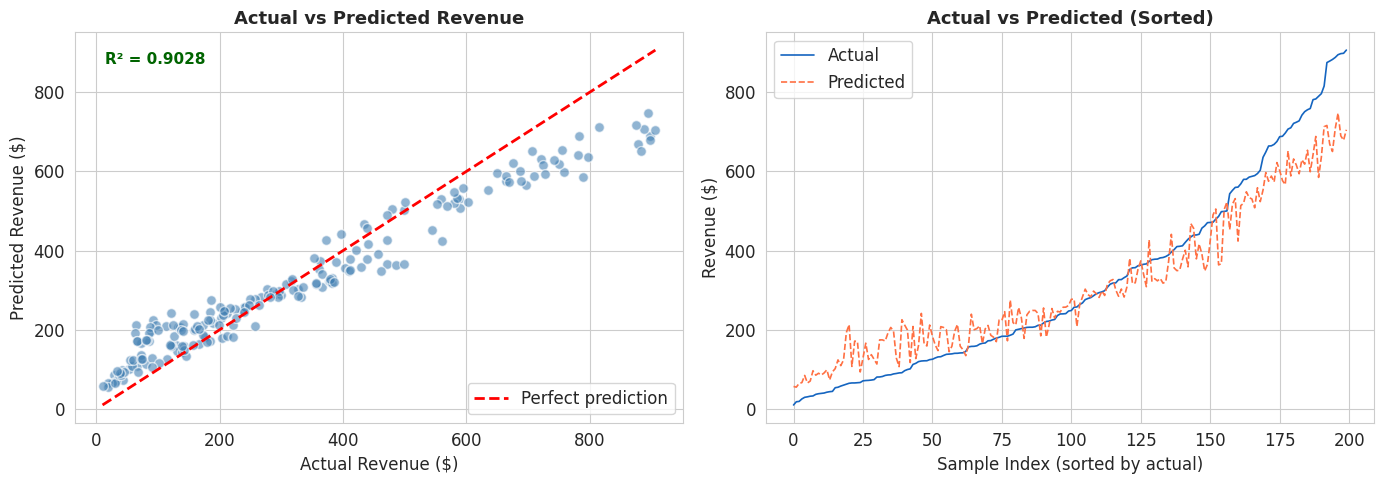

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolor='white', s=50)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title('Actual vs Predicted Revenue', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Revenue ($)')
axes[0].set_ylabel('Predicted Revenue ($)')
axes[0].legend()
axes[0].text(0.05, 0.95, f'R² = {test_r2:.4f}', transform=axes[0].transAxes,
             fontsize=11, va='top', color='darkgreen', fontweight='bold')

# Line plot: y_test vs y_pred (sorted by actual)
sorted_idx = np.argsort(y_test.values)
axes[1].plot(range(len(y_test)), y_test.values[sorted_idx],
             color='#1565C0', label='Actual', linewidth=1.2)
axes[1].plot(range(len(y_pred)), y_pred[sorted_idx],
             color='#FF7043', label='Predicted', linewidth=1.2, linestyle='--')
axes[1].set_title('Actual vs Predicted (Sorted)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sample Index (sorted by actual)')
axes[1].set_ylabel('Revenue ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 9.4 Feature Importance

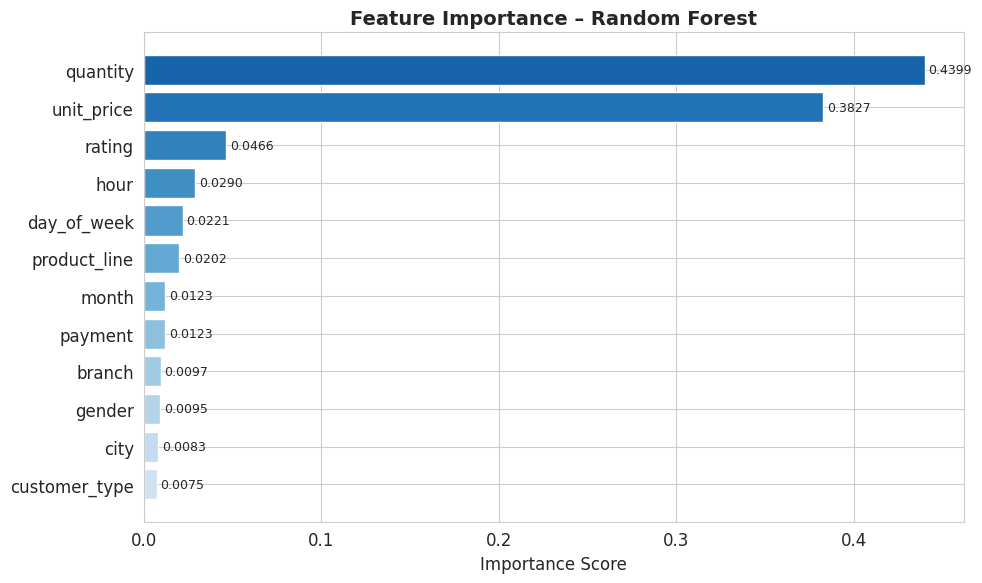

Feature Importance Table:
      Feature  Importance
     quantity    0.439903
   unit_price    0.382687
       rating    0.046594
         hour    0.029048
  day_of_week    0.022069
 product_line    0.020182
        month    0.012272
      payment    0.012268
       branch    0.009746
       gender    0.009455
         city    0.008313
customer_type    0.007462


In [60]:
importances = rf.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Blues_r(np.linspace(0.2, 0.8, len(feat_imp_df)))
bars = ax.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1],
               color=colors[::-1], edgecolor='white')
ax.set_title('Feature Importance – Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, feat_imp_df['Importance'][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Feature Importance Table:")
print(feat_imp_df.to_string(index=False))

---
## 10. Additional Visualizations

### 10.1 Monthly Revenue Trend

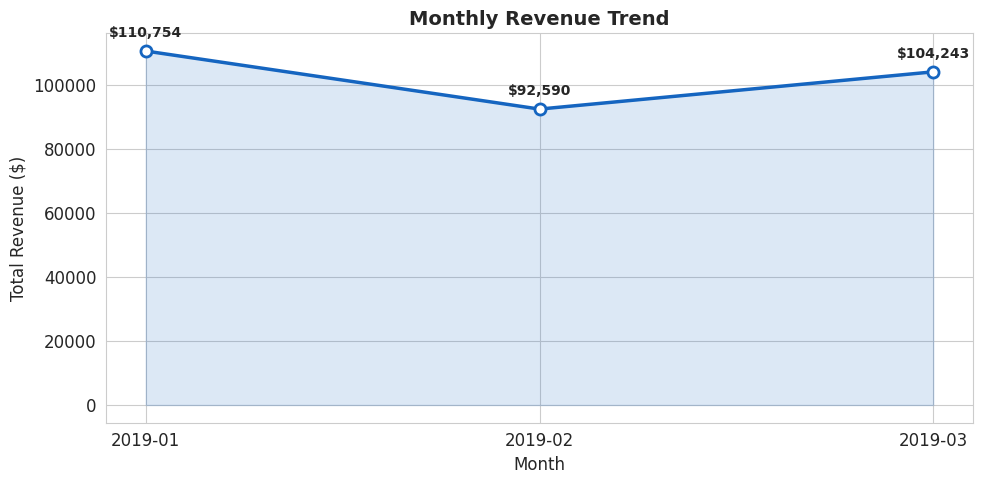

In [61]:
monthly = df_raw.copy()
monthly['Revenue'] = monthly['Unit price'] * monthly['Quantity']
monthly['Date'] = pd.to_datetime(monthly['Date'])
monthly['YearMonth'] = monthly['Date'].dt.to_period('M')
monthly_rev = monthly.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_rev['YearMonth'] = monthly_rev['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_rev['YearMonth'], monthly_rev['Revenue'], marker='o',
        color='#1565C0', linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(monthly_rev['YearMonth'], monthly_rev['Revenue'],
                alpha=0.15, color='#1565C0')
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue ($)')
for i, (m, v) in enumerate(zip(monthly_rev['YearMonth'], monthly_rev['Revenue'])):
    ax.annotate(f'${v:,.0f}', (m, v), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.2 Top 10 Products by Revenue

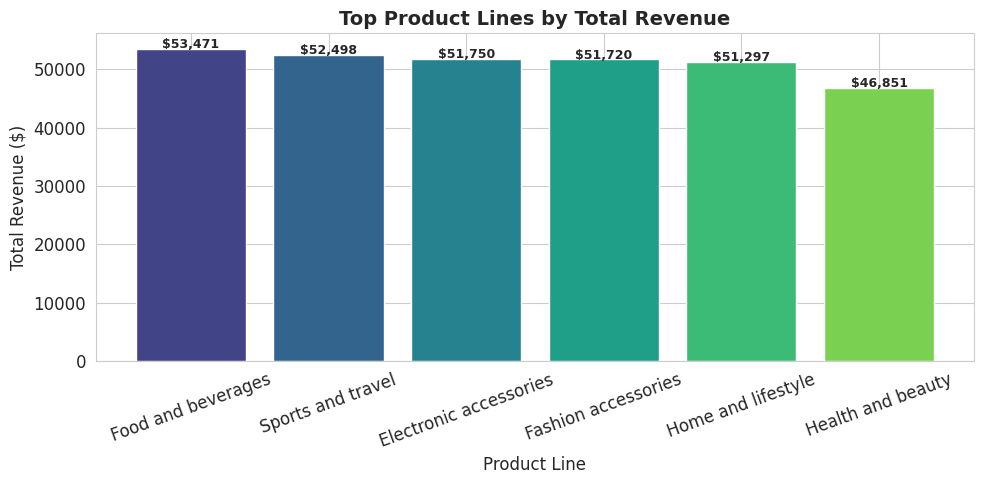

In [62]:
top_products = rev_by_product.groupby('Product line')['Revenue'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
colors_top = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_products)))
bars = ax.bar(top_products.index, top_products.values, color=colors_top, edgecolor='white')
ax.set_title('Top Product Lines by Total Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Product Line')
ax.set_ylabel('Total Revenue ($)')
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, top_products.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.3 Average Revenue by Payment Method

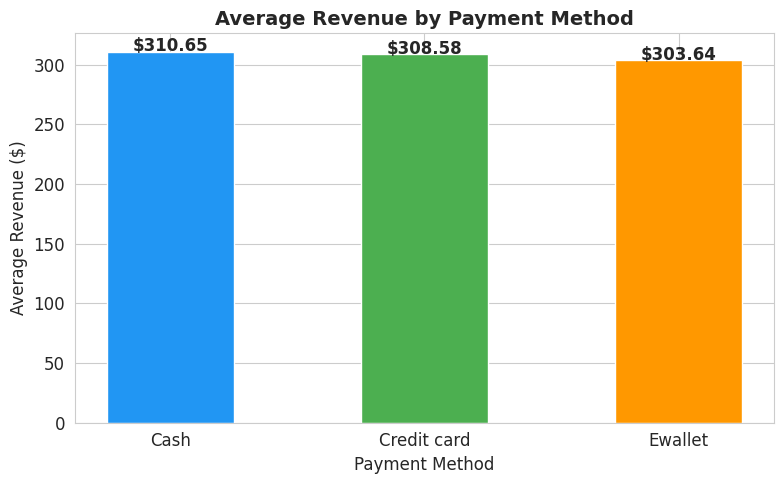

Average Revenue per Transaction by Payment Method:
Payment
Cash           310.65
Credit card    308.58
Ewallet        303.64
Name: Revenue, dtype: float64


In [63]:
avg_pay_rev = rev_by_product.groupby('Payment')['Revenue'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(avg_pay_rev.index, avg_pay_rev.values,
              color=['#2196F3', '#4CAF50', '#FF9800'], edgecolor='white', width=0.5)
ax.set_title('Average Revenue by Payment Method', fontsize=14, fontweight='bold')
ax.set_xlabel('Payment Method')
ax.set_ylabel('Average Revenue ($)')
for bar, val in zip(bars, avg_pay_rev.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'${val:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Average Revenue per Transaction by Payment Method:")
print(avg_pay_rev.round(2))

### 10.4 Pair Plot

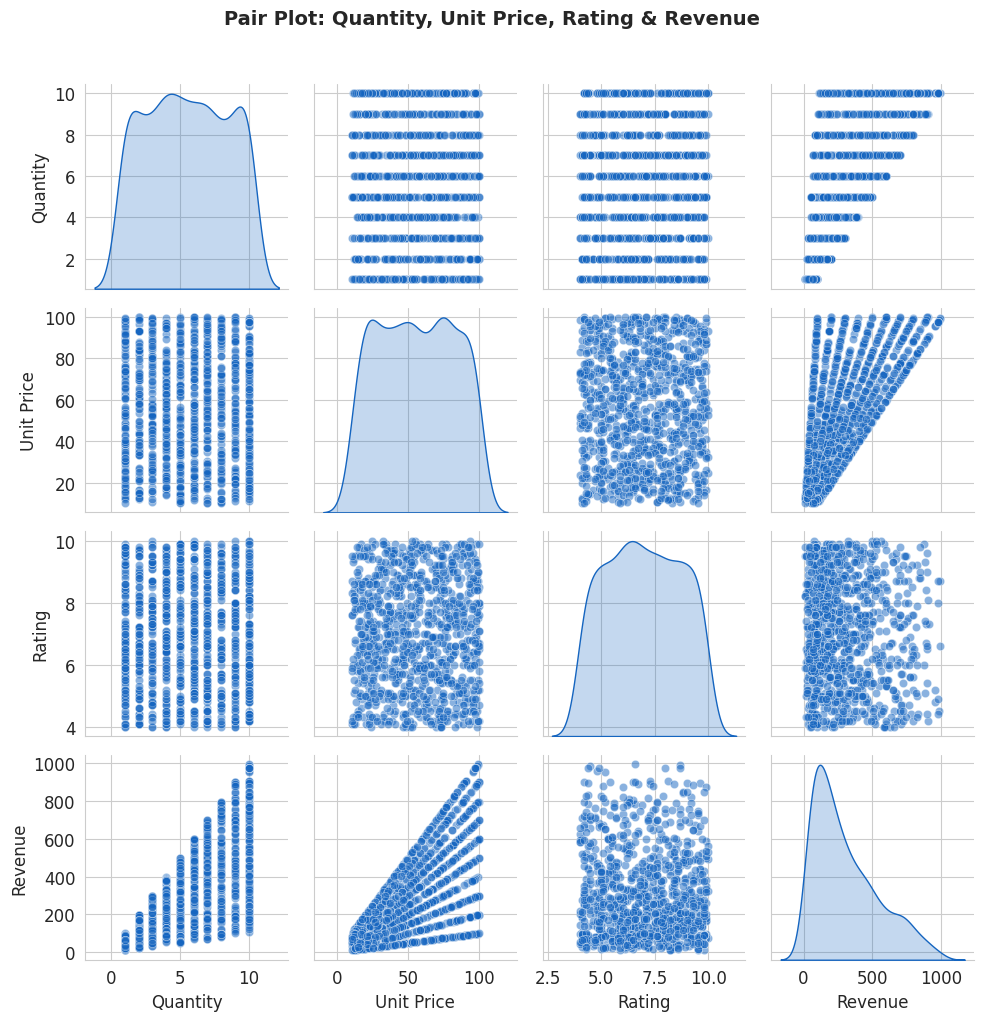

In [64]:
pair_df = pd.DataFrame({
    'Quantity': df_raw['Quantity'],
    'Unit Price': df_raw['Unit price'],
    'Rating': df_raw['Rating'],
    'Revenue': df_raw['Unit price'] * df_raw['Quantity']
})

pair_grid = sns.pairplot(pair_df, diag_kind='kde', plot_kws={'alpha': 0.5, 'color': '#1565C0'},
                         diag_kws={'color': '#1565C0', 'fill': True})
pair_grid.fig.suptitle('Pair Plot: Quantity, Unit Price, Rating & Revenue',
                        fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 11. Final Summary

In [70]:

print("     SUPERMARKET SALES ANALYSIS — SUMMARY")

print(f"\nDataset     : 1,000 transactions × 17 features")
print(f"Target      : Revenue = Unit Price × Quantity")
print(f"Model       : Random Forest Regressor (200 trees)")
print()
print("Performance:")
print(f"  Train R²   : {train_r2*100:.2f}%")
print(f"  Test  R²   : {test_r2*100:.2f}%")
print(f"  Test  MAE  : ${test_mae:.2f}")
print(f"  Test  RMSE : ${test_rmse:.2f}")
print()
top_feat = feat_imp_df.iloc[0]
print(f"Top Feature : {top_feat['Feature']} (importance={top_feat['Importance']:.4f})")
print()
print("Key Insights:")
print(f"  • {city_rev.idxmax()} generates the highest total revenue")
print(f"  • {product_rev.idxmax()} is the top-performing product line")
print(f"  • {payment_counts.idxmax()} is the most used payment method")
print(f"  • {gender_rev.idxmax()} customers generate more total revenue")


     SUPERMARKET SALES ANALYSIS — SUMMARY

Dataset     : 1,000 transactions × 17 features
Target      : Revenue = Unit Price × Quantity
Model       : Random Forest Regressor (200 trees)

Performance:
  Train R²   : 96.89%
  Test  R²   : 90.28%
  Test  MAE  : $59.15
  Test  RMSE : $75.75

Top Feature : quantity (importance=0.4399)

Key Insights:
  • Naypyitaw generates the highest total revenue
  • Food and beverages is the top-performing product line
  • Ewallet is the most used payment method
  • Female customers generate more total revenue
